# Explore the CIC-IDS2017 data

In [5]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_FOLDER = PROJECT_ROOT / "dataset/CSVs/MachineLearningCSV"
PROCESSED_FOLDER = PROJECT_ROOT / "dataset/processed"
LABEL_COLUMNS = {"attack_label", "attack_category", "is_attack"}
# print("Project:", PROJECT_ROOT)

## 1. Available CSV files

In [6]:
csv_files = sorted(CSV_FOLDER.glob("*.csv"))

file_table = pd.DataFrame({
    "file": [file.name for file in csv_files],
    "size_mb": [file.stat().st_size / 1024**2 for file in csv_files],
})
file_table.loc["Total", "size_mb"] = file_table["size_mb"].sum()
file_table

,file,size_mb
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,73.551
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,73.343
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,55.615
3,Monday-WorkingHours.pcap_ISCX.csv,168.732
4,Thursday-WorkingHours-Afternoon-Infilteration....,79.253
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,49.613
6,Tuesday-WorkingHours.pcap_ISCX.csv,128.821
7,Wednesday-workingHours.pcap_ISCX.csv,214.735
Total,NaN,843.664


## 2. Raw rows and columns

In [7]:
raw_sample = pd.read_csv(csv_files[0], nrows=20_000, low_memory=False)
raw_sample.columns = raw_sample.columns.str.strip()

print(f"Sample rows: {len(raw_sample):,}")
print(f"Raw columns: {len(raw_sample.columns)}")
display(raw_sample.head())

Sample rows: 20,000
Raw columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.000,0.000,0,0,0.000,0.000,"4,000,000.000","666,666.667",3.000,0.000,3,3,3,3.000,0.000,3,3,0,0.000,0.000,0,0,0,0,0,0,40,0,"666,666.667",0.000,6,6,6.000,0.000,0.000,0,0,0,0,1,0,0,0,0,9.000,6.000,0.000,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.000,0.000,6,6,6.000,0.000,"110,091.743","18,348.624",109.000,0.000,109,109,0,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0,0,20,20,"9,174.312","9,174.312",6,6,6.000,0.000,0.000,0,0,0,0,1,1,0,0,1,9.000,6.000,6.000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.000,0.000,6,6,6.000,0.000,"230,769.231","38,461.538",52.000,0.000,52,52,0,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0,0,20,20,"19,230.769","19,230.769",6,6,6.000,0.000,0.000,0,0,0,0,1,1,0,0,1,9.000,6.000,6.000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.000,0.000,6,6,6.000,0.000,"352,941.177","58,823.529",34.000,0.000,34,34,0,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0,0,20,20,"29,411.765","29,411.765",6,6,6.000,0.000,0.000,0,0,0,0,1,1,0,0,1,9.000,6.000,6.000,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.000,0.000,0,0,0.000,0.000,"4,000,000.000","666,666.667",3.000,0.000,3,3,3,3.000,0.000,3,3,0,0.000,0.000,0,0,0,0,0,0,40,0,"666,666.667",0.000,6,6,6.000,0.000,0.000,0,0,0,0,1,0,0,0,0,9.000,6.000,0.000,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN


In [8]:
column_table = pd.DataFrame({
    "column": raw_sample.columns,
    "data_type": raw_sample.dtypes.astype(str).values,
    "example": [raw_sample[column].iloc[0] for column in raw_sample.columns],
})
column_table

,column,data_type,example
0,Destination Port,int64,54865
1,Flow Duration,int64,3
2,Total Fwd Packets,int64,2
3,Total Backward Packets,int64,0
4,Total Length of Fwd Packets,int64,12
...,...,...,...
74,Idle Mean,float64,0.000
75,Idle Std,float64,0.000
76,Idle Max,int64,0
77,Idle Min,int64,0


## 3. Traffic labels

In [9]:
DAMAGED_SEPARATORS = (chr(0xFFFD), chr(0x96), chr(0x2013), chr(0x2014))

ATTACK_CATEGORIES = {
    "Web Attack - Brute Force": "Web Attack",
    "Web Attack - Sql Injection": "Web Attack",
    "Web Attack - XSS": "Web Attack",
}


def clean_label_names(labels):
    cleaned = labels.astype("string").str.strip()
    for character in DAMAGED_SEPARATORS:
        cleaned = cleaned.str.replace(character, "-", regex=False)
    return cleaned.str.replace(r"\s+", " ", regex=True)


all_labels = []
for file in tqdm(csv_files, desc="Reading labels", unit="file"):
    labels = pd.read_csv(
        file, usecols=lambda column: column.strip() == "Label"
    ).iloc[:, 0]
    all_labels.append(clean_label_names(labels))

raw_labels = pd.concat(all_labels, ignore_index=True)
label_counts = raw_labels.value_counts().rename_axis("label").to_frame("rows")
label_counts["percent"] = 100 * label_counts["rows"] / label_counts["rows"].sum()
display(label_counts)

Reading labels:   0%|          | 0/8 [00:00<?, ?file/s]

,rows,percent
label,,
BENIGN,2273097,80.300
DoS Hulk,231073,8.163
PortScan,158930,5.614
DDoS,128027,4.523
DoS GoldenEye,10293,0.364
FTP-Patator,7938,0.280
SSH-Patator,5897,0.208
DoS slowloris,5796,0.205
DoS Slowhttptest,5499,0.194


In [10]:
categories = raw_labels.map(lambda name: ATTACK_CATEGORIES.get(name, name))
category_counts = categories.value_counts().rename_axis("category").to_frame("rows")
category_counts["percent"] = 100 * category_counts["rows"] / category_counts["rows"].sum()
display(category_counts)

,rows,percent
category,,
BENIGN,2273097,80.300
DoS Hulk,231073,8.163
PortScan,158930,5.614
DDoS,128027,4.523
DoS GoldenEye,10293,0.364
FTP-Patator,7938,0.280
SSH-Patator,5897,0.208
DoS slowloris,5796,0.205
DoS Slowhttptest,5499,0.194


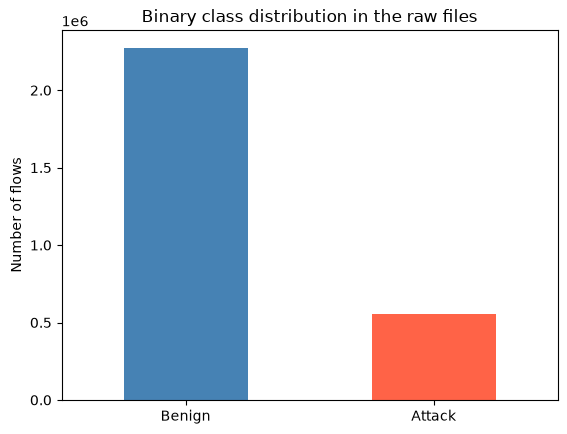

Attacks are 19.70% of the raw flows.
The classes are unbalanced, so recall and F1-score matter as much as accuracy.


In [11]:
is_attack = raw_labels != "BENIGN"
binary_counts = pd.Series({
    "Benign": int((~is_attack).sum()),
    "Attack": int(is_attack.sum()),
})

binary_counts.plot(kind="bar", color=["steelblue", "tomato"], rot=0)
plt.title("Binary class distribution in the raw files")
plt.ylabel("Number of flows")
plt.show()

share = binary_counts["Attack"] / binary_counts.sum() * 100
print(f"Attacks are {share:.2f}% of the raw flows.")
print("The classes are unbalanced, so recall and F1-score matter as much as accuracy.")

## 4. Cleaning results

In [12]:
report_path = PROCESSED_FOLDER / "preprocessing_report.json"
if not report_path.exists():
    raise FileNotFoundError("Run notebooks/00_complete_pipeline.ipynb first.")

report = json.loads(report_path.read_text(encoding="utf-8"))
display(pd.Series({
    key: value for key, value in report.items() if not isinstance(value, (list, dict))
}).to_frame("value"))

removed = report["input"] - report["retained"]
print(f"Removed rows: {removed:,} ({removed / report['input']:.2%} of the input)")
print(f"  invalid (missing values or infinite rates): {report['invalid']:,}")
print(f"  exact duplicates:                          {report['duplicates']:,}")

,value
input,2830743
invalid,2867
duplicates,329896
retained,2497980
train,1998384
test,499596
features,77


Removed rows: 332,763 (11.76% of the input)
  invalid (missing values or infinite rates): 2,867
  exact duplicates:                          329,896


In [9]:
display(pd.DataFrame({
    "train": report["train_attack_categories"],
    "test": report["test_attack_categories"],
}).fillna(0).astype(int))
print("The split is stratified by attack label, so every class is in both partitions.")

,train,test
BENIGN,1657803,414451
Bot,1558,390
DDoS,102411,25603
DoS GoldenEye,8226,2056
DoS Hulk,138277,34569
DoS Slowhttptest,4182,1046
DoS slowloris,4299,1075
FTP-Patator,4745,1186
Heartbleed,9,2
Infiltration,29,7


The split is stratified by attack label, so every class is in both partitions.


## 5. The processed datasets

In [13]:
train_path = PROCESSED_FOLDER / "train.parquet"
test_path = PROCESSED_FOLDER / "test.parquet"


def parquet_info(path):
    parquet = pq.ParquetFile(path)
    return {
        "file": path.name,
        "rows": parquet.metadata.num_rows,
        "columns": parquet.metadata.num_columns,
        "size_mb": path.stat().st_size / 1024**2,
    }


pd.DataFrame([parquet_info(train_path), parquet_info(test_path)])

,file,rows,columns,size_mb
0,train.parquet,1998384,80,210.804
1,test.parquet,499596,80,53.248


In [15]:
train_file = pq.ParquetFile(train_path)
train_sample = train_file.read_row_group(0).to_pandas().head(50_000)

print(f"Loaded {len(train_sample):,} rows for exploration")
display(train_sample.head())

Loaded 50,000 rows for exploration


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,attack_label,attack_category,is_attack
0,-0.457,-0.474,-0.010,-0.009,-0.049,-0.007,-0.268,0.163,-0.177,-0.262,-0.444,0.437,-0.424,-0.430,-0.006,-0.115,-0.312,-0.390,-0.403,-0.056,-0.465,-0.293,-0.364,-0.396,-0.126,-0.370,-0.217,-0.253,-0.292,-0.124,-0.227,0.000,-0.006,0.000,0.001,0.002,-0.150,0.145,0.481,-0.469,-0.453,-0.465,-0.316,-0.183,-0.227,-0.017,-0.655,-0.675,-0.337,-0.006,-0.017,0.438,-0.447,-0.177,-0.424,0.000,0.000,0.000,0.000,0.000,0.000,-0.010,-0.049,-0.009,-0.007,-0.500,-0.251,-0.007,0.003,-0.135,-0.113,-0.160,-0.108,-0.378,-0.117,-0.383,-0.364,BENIGN,BENIGN,0
1,-0.016,-0.474,-0.012,-0.010,-0.053,-0.008,-0.299,-0.214,-0.294,-0.262,-0.478,-0.520,-0.531,-0.430,-0.044,-0.033,-0.312,-0.390,-0.403,-0.056,-0.465,-0.293,-0.364,-0.396,-0.126,-0.370,-0.217,-0.253,-0.292,-0.124,-0.227,0.000,-0.006,0.000,0.001,0.002,-0.106,0.364,-0.416,-0.501,-0.582,-0.502,-0.316,-0.183,-0.227,-0.017,-0.655,1.481,2.969,-0.006,-0.017,0.438,-0.591,-0.294,-0.531,0.000,0.000,0.000,0.000,0.000,0.000,-0.012,-0.053,-0.010,-0.008,-0.477,-0.223,-0.009,0.003,-0.135,-0.113,-0.160,-0.108,-0.378,-0.117,-0.383,-0.364,BENIGN,BENIGN,0
2,-0.437,-0.474,-0.010,-0.011,-0.054,-0.008,-0.307,-0.313,-0.325,-0.262,-0.480,-0.604,-0.540,-0.430,-0.053,-0.158,-0.312,-0.390,-0.403,-0.056,-0.465,-0.293,-0.364,-0.396,-0.126,-0.370,-0.217,-0.253,-0.292,-0.124,-0.227,0.000,-0.006,0.000,0.001,0.002,-0.132,-0.170,-0.650,-0.504,-0.601,-0.502,-0.316,-0.183,-0.227,-0.017,-0.655,1.481,-0.337,-0.006,-0.017,-1.014,-0.616,-0.325,-0.540,0.000,0.000,0.000,0.000,0.000,0.000,-0.010,-0.054,-0.011,-0.008,-0.475,-0.251,-0.009,0.003,-0.135,-0.113,-0.160,-0.108,-0.378,-0.117,-0.383,-0.364,BENIGN,BENIGN,0
3,-0.437,2.882,0.007,0.002,-0.004,-0.006,-0.054,-0.313,-0.141,-0.055,0.213,-0.604,-0.011,0.215,-0.053,-0.234,0.566,1.401,1.882,-0.056,2.907,0.495,1.670,1.882,-0.126,3.550,0.749,3.065,2.953,-0.124,-0.227,0.000,-0.006,0.000,0.001,0.002,-0.212,-0.170,-0.650,0.162,-0.067,0.112,-0.221,-0.183,-0.227,-0.017,1.527,-0.675,-0.337,-0.006,-0.017,-1.014,-0.109,-0.141,-0.011,0.000,0.000,0.000,0.000,0.000,0.000,0.007,-0.004,0.002,-0.006,1.497,-0.212,-0.000,0.003,0.495,1.088,0.560,0.022,1.984,-0.100,1.908,2.019,BENIGN,BENIGN,0
4,-0.457,-0.474,-0.012,-0.010,-0.049,-0.007,-0.238,0.541,-0.060,-0.262,-0.420,1.141,-0.345,-0.430,-0.040,-0.214,-0.312,-0.390,-0.403,-0.056,-0.465,-0.293,-0.364,-0.396,-0.126,-0.370,-0.217,-0.253,-0.292,-0.124,-0.227,0.000,-0.006,0.000,0.001,0.002,-0.201,-0.117,1.378,-0.445,-0.363,-0.439,-0.315,-0.183,-0.227,-0.017,-0.655,-0.675,-0.337,-0.006,-0.017,0.438,-0.287,-0.060,-0.345,0.000,0.000,0.000,0.000,0.000,0.000,-0.012,-0.049,-0.010,-0.007,-0.500,-0.251,-0.009,0.003,-0.135,-0.113,-0.160,-0.108,-0.378,-0.117,-0.383,-0.364,BENIG

In [16]:
feature_columns = [
    column for column in train_sample.columns if column not in LABEL_COLUMNS
]

quality_check = {
    "sample_rows": len(train_sample),
    "feature_columns": len(feature_columns),
    "label_columns": len(LABEL_COLUMNS),
    "missing_cells": int(train_sample.isna().sum().sum()),
    "infinite_feature_cells": int(np.isinf(train_sample[feature_columns].to_numpy()).sum()),
}
pd.Series(quality_check).to_frame("value")

,value
sample_rows,50000
feature_columns,77
label_columns,3
missing_cells,0
infinite_feature_cells,0


## 6. Example features

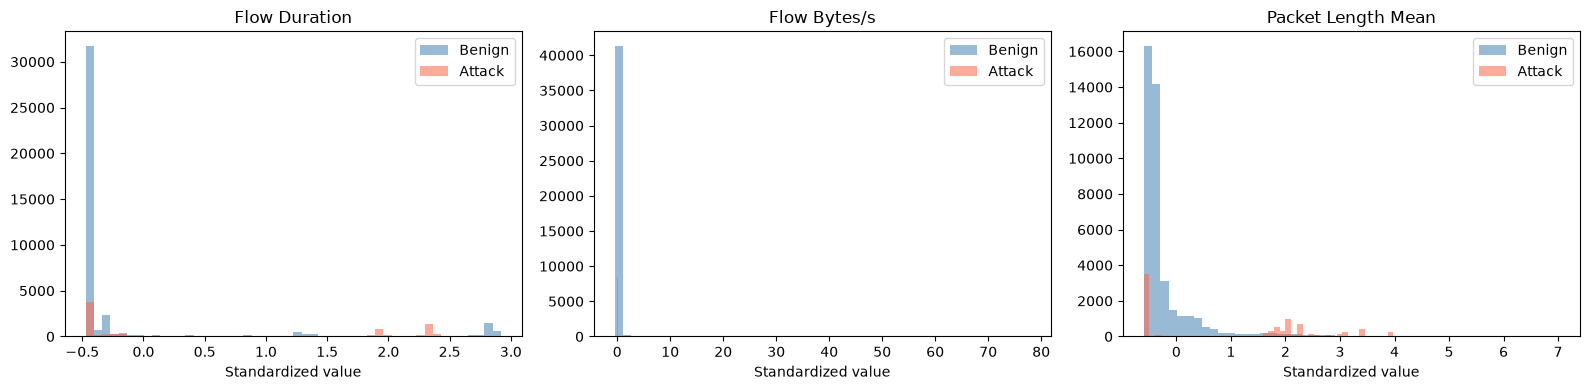

In [18]:
plot_features = ["Flow Duration", "Flow Bytes/s", "Packet Length Mean"]
colors = {0: "steelblue", 1: "tomato"}
names = {0: "Benign", 1: "Attack"}

fig, axes = plt.subplots(1, len(plot_features), figsize=(16, 4))
for axis, feature in zip(axes, plot_features):
    for label in [0, 1]:
        values = train_sample.loc[train_sample["is_attack"] == label, feature]
        axis.hist(values, bins=50, alpha=0.55, label=names[label], color=colors[label])
    axis.set_title(feature)
    axis.set_xlabel("Standardized value")
    axis.legend()

plt.tight_layout()
plt.show()